# HANDWRITTEN DIGITS RECOGNITION

## 1. PACKAGES

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt

import helper_utils

In [2]:
train_dataset_without_transform = torchvision.datasets.MNIST(
    root='./data',     # Path to the directory where the data is/will be stored
    train=True,         # Specify that you want the training split of the dataset
    download=True       # Download the data if it's not found in the root directory
)
# Get the first sample (index 0), as a (image, label) tuple
image_pil, label = train_dataset_without_transform[0] # Get the first image

print(f"Image type:        {type(image_pil)}")
# Since `image_pil` is a PIL Image object, its dimensions are accessed using the .size attribute.
print(f"Image Dimensions:  {image_pil.size}")
print(f"Label Type:        {type(label)}")
print(f"Label value:       {label}")

Image type:        <class 'PIL.Image.Image'>
Image Dimensions:  (28, 28)
Label Type:        <class 'int'>
Label value:       5


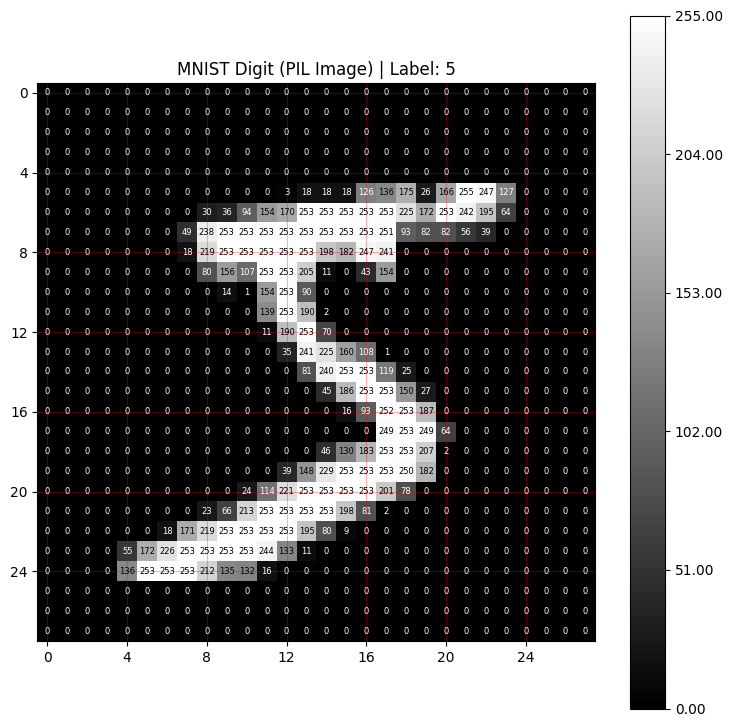

In [3]:
# Visualize the sample image and its corresponding label
helper_utils.display_image(image_pil, label, "MNIST Digit (PIL Image)", show_values=True)

## 2. DATA PIPELINE

In [4]:
# Data preprocessing
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.1307,), (0.3081,)) # two numbers are represented for mean and standard deviation for the whole dataset
])

### Load MNIST Dataset

In [5]:
#load MNIST dataset
train_dataset = torchvision.datasets.MNIST(
    root='./data', train=True, transform=transform, download=True)
test_dataset = torchvision.datasets.MNIST(
    root='./data', train=False, transform=transform, download = True)

In [6]:
# Access the first item again
image_tensor, label = train_dataset[0]

print(f"Image Type:                   {type(image_tensor)}")
# Since the `image` is now a PyTorch Tensor, its dimensions are accessed using the .shape attribute.
print(f"Image Shape After Transform:  {image_tensor.shape}")
print(f"Label Type:                   {type(label)}")
print(f"Label value:                  {label}")

Image Type:                   <class 'torch.Tensor'>
Image Shape After Transform:  torch.Size([1, 28, 28])
Label Type:                   <class 'int'>
Label value:                  5


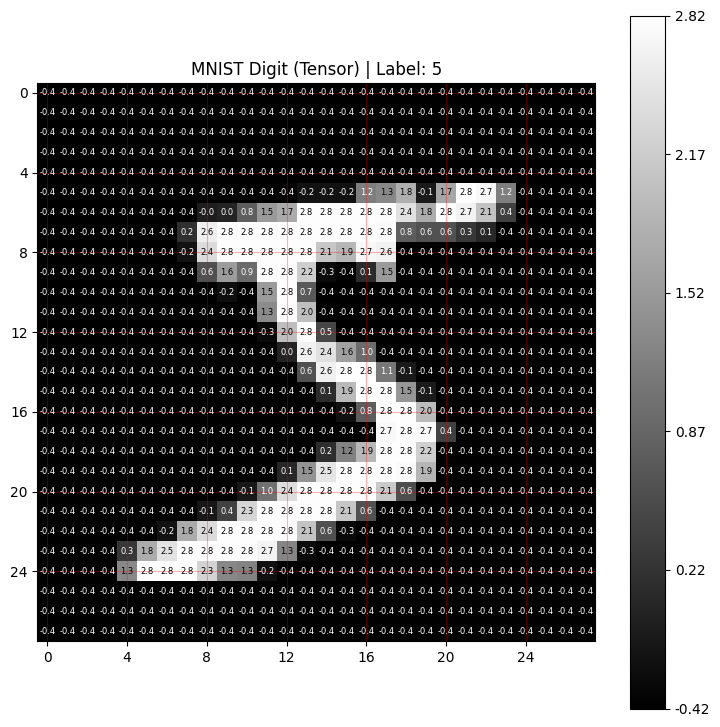

In [7]:
# Visualize the transformed image and its label
helper_utils.display_image(image_tensor, label, "MNIST Digit (Tensor)", show_values=True)

### Create data loaders

In [8]:
# Create data loaders
train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=1000, shuffle=False)

## 3. Building a neural network

In [38]:
class MNISTClassifier(nn.Module):
    def __init__(self):m
        super().__init__()
        self.Flatten = nn.Flatten() #make the 2D image to 1D vector
        self.layers = nn.Sequential(
            nn.Linear(784, 392),
            nn.ReLU(),
            nn.Linear(392, 128),
            nn.ReLU(),
            nn.Linear(128, 10)
        )

    def forward(self, x):
        x = self.Flatten(x)
        x = self.layers(x)
        return x

## 4. Device and Optimizer

In [39]:
# Check for GPU
if torch.cuda.is_available():
    device = torch.device("cuda")
    print(f"Using device: CUDA")
elif torch.backends.mps.is_available():
    device = torch.device("mps")
    print(f"Using device: MPS (Apple Silicon GPU)")
else:
    device = torch.device("cpu")
    print(f"Using device: CPU")

# Initialize model and move to device
model = MNISTClassifier().to(device)

# Loss function and Optimizer
loss_function = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

Using device: MPS (Apple Silicon GPU)


In [40]:
def train_epoch(model, loss_function, optimizer, train_loader,  device):
    model = model.to(device)
    model.train()

    epoch_loss = 0.0
    running_loss = 0.0
    num_correct_predictions = 0
    total_predictions = 0
    total_batches = len(train_loader)

    for batch_idx, (inputs, targets) in enumerate(train_loader):
        inputs, targets = inputs.to(device), targets.to(device)

        optimizer.zero_grad()
        outputs = model(inputs)
        loss = loss_function(outputs, targets)
        loss.backward()
        optimizer.step()

        # Track progress
        loss_value = loss.item()
        epoch_loss += loss_value
        running_loss += loss_value

        _, predicted_indices = outputs.max(1)
        batch_size = targets.size(0)
        total_predictions += batch_size
        num_correct_predictions += predicted_indices.eq(targets).sum().item()

        if ((batch_idx + 1) % 134 == 0 or (batch_idx + 1) == total_batches):
            # Calculate average loss and accuracy for the current interval
            avg_running_loss = running_loss / 134
            accuracy = 100. * num_correct_predictions / total_predictions
            
            # Print the progress update
            print(f'\tStep {batch_idx + 1}/{total_batches} - Loss: {avg_running_loss:.3f} | Acc: {accuracy:.2f}%')
            
            # Reset the trackers for the next reporting interval
            running_loss = 0.0
            num_correct_predictions = 0
            total_predictions = 0
            
    avg_epoch_loss = epoch_loss / total_batches
    # Return the trained model and the average epoch loss
    return model, avg_epoch_loss

### Evaluation

In [41]:
def evaluate(model, test_loader, device):
    model.eval()
    num_correct_predictions = 0
    total_predictions = 0
    with torch.no_grad():
        # Iterates over all batches in the test data loader.
        for inputs, targets in test_loader:
            inputs, targets = inputs.to(device), targets.to(device)
            
            outputs = model(inputs)
            
            _, predicted_indices = outputs.max(1)
            
            batch_size = targets.size(0)
            total_predictions = total_predictions + batch_size
            
            correct_predictions = predicted_indices.eq(targets)
            num_correct_in_batch = correct_predictions.sum().item()
            num_correct_predictions = num_correct_predictions + num_correct_in_batch

    accuracy_percentage = (num_correct_predictions / total_predictions) * 100
    print((f'\tAccuracy - {accuracy_percentage:.2f}%'))

## Put all together

In [42]:
# Training loop
num_epochs = 10
train_loss = []
test_acc = []

# Begin the training and evaluation process
for epoch in range(num_epochs):
    print(f'\n[Training] Epoch {epoch+1}:')
    trained_model, loss = train_epoch(model, loss_function, optimizer, train_loader, device)
    train_loss.append(loss)
    
    print(f'[Testing] Epoch {epoch+1}:')
    # Call the evaluation function to measure performance on the test set
    accuracy = evaluate(trained_model, test_loader, device)
    # Store the test accuracy for the epoch
    test_acc.append(accuracy)


[Training] Epoch 1:
	Step 134/938 - Loss: 0.507 | Acc: 84.98%
	Step 268/938 - Loss: 0.245 | Acc: 92.62%
	Step 402/938 - Loss: 0.189 | Acc: 94.43%
	Step 536/938 - Loss: 0.147 | Acc: 95.57%
	Step 670/938 - Loss: 0.140 | Acc: 95.55%
	Step 804/938 - Loss: 0.141 | Acc: 95.86%
	Step 938/938 - Loss: 0.130 | Acc: 96.27%
[Testing] Epoch 1:
	Accuracy - 96.44%

[Training] Epoch 2:
	Step 134/938 - Loss: 0.091 | Acc: 97.21%
	Step 268/938 - Loss: 0.095 | Acc: 97.17%
	Step 402/938 - Loss: 0.090 | Acc: 97.14%
	Step 536/938 - Loss: 0.083 | Acc: 97.40%
	Step 670/938 - Loss: 0.092 | Acc: 97.00%
	Step 804/938 - Loss: 0.084 | Acc: 97.42%
	Step 938/938 - Loss: 0.084 | Acc: 97.53%
[Testing] Epoch 2:
	Accuracy - 96.19%

[Training] Epoch 3:
	Step 134/938 - Loss: 0.061 | Acc: 98.18%
	Step 268/938 - Loss: 0.067 | Acc: 97.73%
	Step 402/938 - Loss: 0.055 | Acc: 98.18%
	Step 536/938 - Loss: 0.059 | Acc: 98.15%
	Step 670/938 - Loss: 0.074 | Acc: 97.66%
	Step 804/938 - Loss: 0.055 | Acc: 98.27%
	Step 938/938 - Loss:

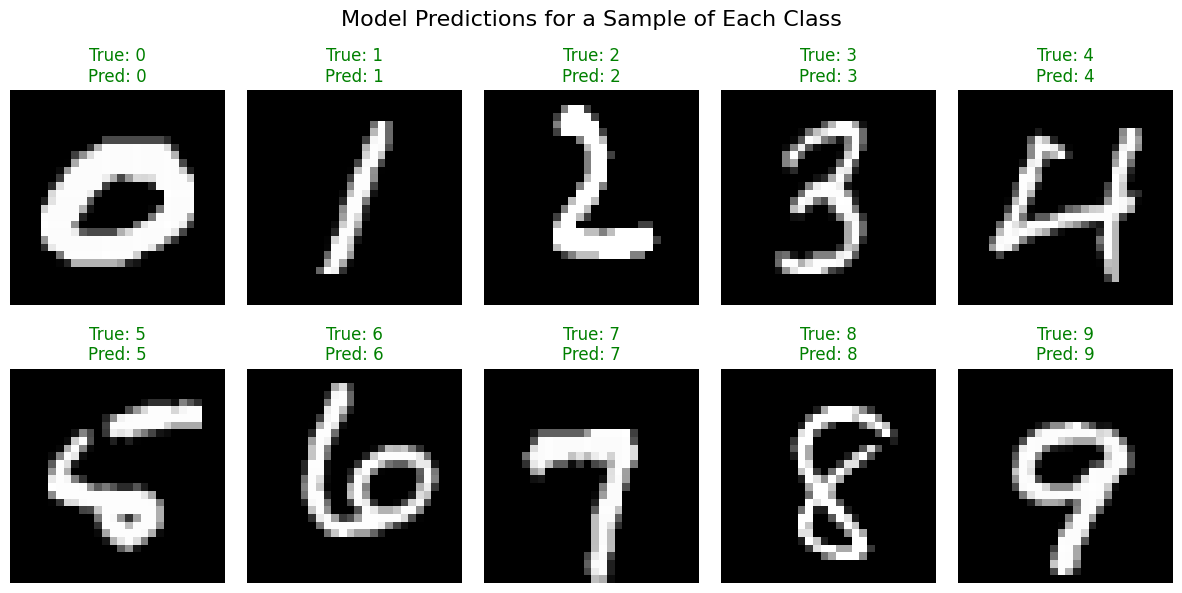

In [43]:
# Visualize model predictions on a random sample of test images
helper_utils.display_predictions(trained_model, test_loader, device)